# ⚙️ La Máquina de la Dependencia
**Análisis Multidimensional de la política de vivienda subsidiada en Chile**\n
*Tesis central: El Estado chileno construye viviendas subsidiadas en la periferia por el bajo costo del suelo. Esto entrega un activo a las familias (la casa), pero las aísla en entornos con alta precariedad multidimensional (delincuencia, hacinamiento, falta de acceso). En lugar de ser un trampolín para la autonomía, la vivienda subsidiada correlaciona con un estancamiento en la pobreza y peores condiciones de vida.*

In [1]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Estilo de visualización minimalista y profesional
plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = False

# Paletas de color
COLOR_SUB = '#d94c4c'   # Rojo: Representa la trampa, el entorno crítico y la dependencia
COLOR_NO_SUB = '#2b7a78' # Verde: Representa la integración y la autonomía
COLOR_METRO = '#34495e'  # Gris oscuro (Ciudad)
COLOR_REGIONES = '#95a5a6' # Gris claro (Regiones)

## 1. Carga de Datos y Dimensiones CASEN 2024
Cargamos la base de datos y calculamos las agregaciones tanto a nivel de MacroZona (Metropolitana vs Regiones) como a nivel de cada una de las 16 regiones específicas.

In [2]:
print("Cargando el ecosistema CASEN 2024...")
columnas_casen = [
    'id_persona', 'region', 'expr', 'yautcorh', 'pobreza_multi', 'v15', 
    'hh_d_entorno_2015', 'hh_d_seg_2015', 'hh_d_hacina_2015', 
    'hh_d_estado_2015', 'hh_d_accesi_2015'
]
df_pandas = pd.read_stata("../data/raw/casen_2024.dta", columns=columnas_casen, convert_categoricals=False)

df = pl.from_pandas(df_pandas)
df_hogares = df.filter(pl.col("id_persona") == 1)
df_analisis = df_hogares.filter(pl.col("v15").is_in([1, 2]))

df_analisis = df_analisis.with_columns(
    pl.when(pl.col("v15") == 1).then(pl.lit("Con Subsidio"))
    .when(pl.col("v15") == 2).then(pl.lit("Sin Subsidio")).alias("Subsidio"),
    pl.when(pl.col("region") == 13).then(pl.lit("Metropolitana")).otherwise(pl.lit("Regiones")).alias("MacroZona")
)

# Mapeo oficial de regiones de Norte a Sur para mantener orden geográfico
dicc_regiones = {
    15: 'Arica y Parinacota', 1: 'Tarapacá', 2: 'Antofagasta', 3: 'Atacama', 4: 'Coquimbo',
    5: 'Valparaíso', 13: 'Metropolitana', 6: "O'Higgins", 7: 'Maule', 16: 'Ñuble', 8: 'Biobío',
    9: 'Araucanía', 14: 'Los Ríos', 10: 'Los Lagos', 11: 'Aysén', 12: 'Magallanes'
}

df_analisis = df_analisis.with_columns(
    pl.col("region").map_elements(lambda x: dicc_regiones.get(x, "N/A"), return_dtype=pl.String).alias("Nombre_Region")
)

# --- 1. Agregación MACROZONA (SIN CONSIDERAR SUBSIDIO) ---
resumen_macro = df_analisis.group_by(["MacroZona"]).agg([
    (((pl.col("pobreza_multi") * pl.col("expr")).sum() / pl.col("expr").sum()) * 100).round(1).alias("Pobreza_%"),
    (((pl.col("hh_d_seg_2015") * pl.col("expr")).sum() / pl.col("expr").sum()) * 100).round(1).alias("Seguridad_%"),
    (((pl.col("hh_d_entorno_2015") * pl.col("expr")).sum() / pl.col("expr").sum()) * 100).round(1).alias("Entorno_%"),
    (((pl.col("hh_d_hacina_2015") * pl.col("expr")).sum() / pl.col("expr").sum()) * 100).round(1).alias("Hacinamiento_%"),
    (((pl.col("hh_d_estado_2015") * pl.col("expr")).sum() / pl.col("expr").sum()) * 100).round(1).alias("Estado_Vivienda_%"),
    (((pl.col("hh_d_accesi_2015") * pl.col("expr")).sum() / pl.col("expr").sum()) * 100).round(1).alias("Accesibilidad_%"),
    pl.col("yautcorh").median().round(0).alias("Ingreso_Mediano")
]).sort(["MacroZona"])
df_grafico_macro = resumen_macro.to_pandas()

# --- 2. Agregación 16 REGIONES (Específico, CON SUBSIDIO) ---
resumen_regional = df_analisis.group_by(["region", "Nombre_Region", "Subsidio"]).agg([
    (((pl.col("pobreza_multi") * pl.col("expr")).sum() / pl.col("expr").sum()) * 100).round(1).alias("Pobreza_%"),
    (((pl.col("hh_d_seg_2015") * pl.col("expr")).sum() / pl.col("expr").sum()) * 100).round(1).alias("Seguridad_%"),
    (((pl.col("hh_d_entorno_2015") * pl.col("expr")).sum() / pl.col("expr").sum()) * 100).round(1).alias("Entorno_%"),
    (((pl.col("hh_d_hacina_2015") * pl.col("expr")).sum() / pl.col("expr").sum()) * 100).round(1).alias("Hacinamiento_%"),
    (((pl.col("hh_d_estado_2015") * pl.col("expr")).sum() / pl.col("expr").sum()) * 100).round(1).alias("Estado_Vivienda_%"),
    (((pl.col("hh_d_accesi_2015") * pl.col("expr")).sum() / pl.col("expr").sum()) * 100).round(1).alias("Accesibilidad_%"),
    pl.col("yautcorh").median().round(0).alias("Ingreso_Mediano")
]).sort(["region"])
df_grafico_regional = resumen_regional.to_pandas()

print("Datos procesados exitosamente.")

Cargando el ecosistema CASEN 2024...
Datos procesados exitosamente.


---
## 2. PANORAMA GENERAL: Metropolitana vs Regiones
Observamos el **comportamiento base de los territorios**. Utilizamos un **Dumbbell Plot** (gráfico de mancuernas) que limpia visualmente la diferencia estructural entre la Región Metropolitana y el promedio del resto de las regiones chilenas.

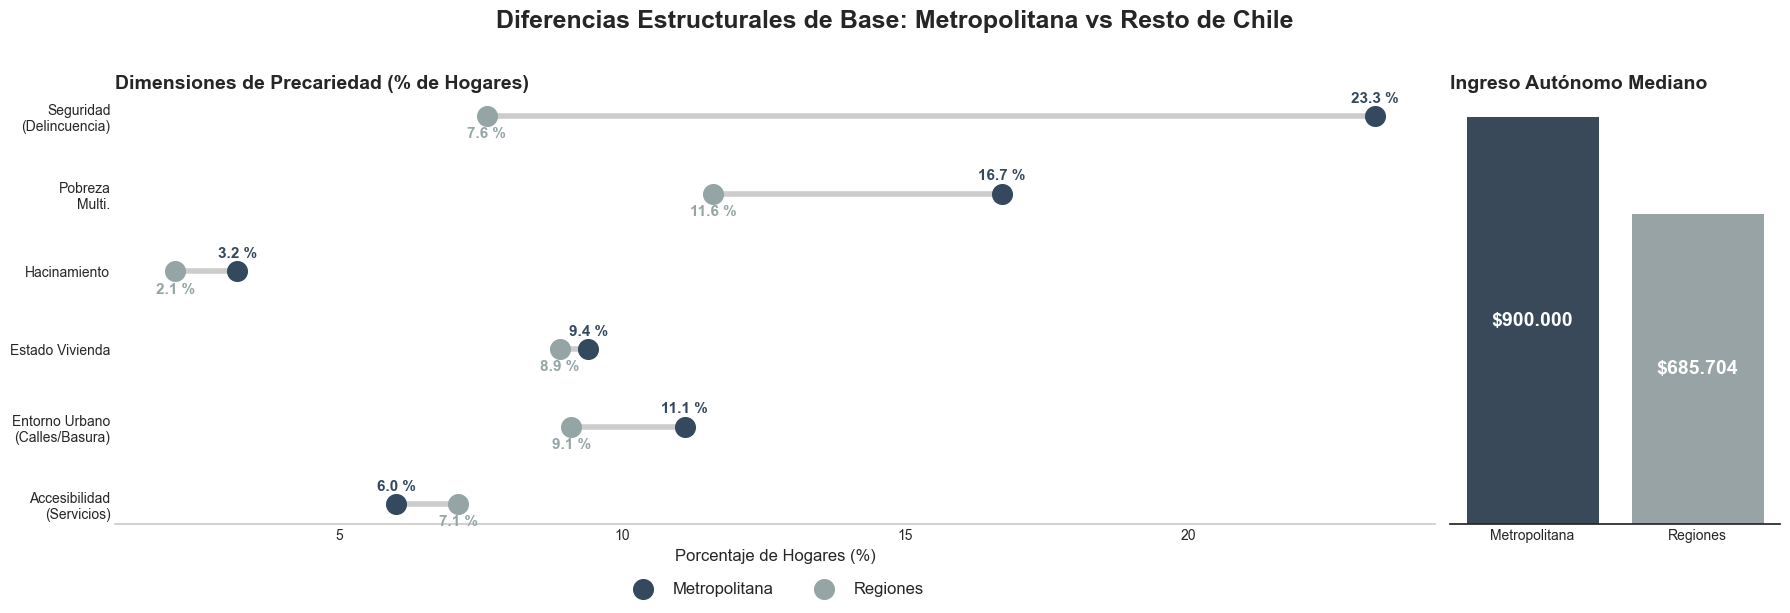

In [3]:
df_melt = df_grafico_macro.melt(id_vars='MacroZona', 
                                value_vars=['Pobreza_%', 'Seguridad_%', 'Entorno_%', 'Hacinamiento_%', 'Estado_Vivienda_%', 'Accesibilidad_%'],
                                var_name='Indicador', value_name='Porcentaje')

df_melt['Indicador'] = df_melt['Indicador'].replace({
    'Pobreza_%': 'Pobreza\nMulti.',
    'Seguridad_%': 'Seguridad\n(Delincuencia)',
    'Entorno_%': 'Entorno Urbano\n(Calles/Basura)',
    'Hacinamiento_%': 'Hacinamiento',
    'Estado_Vivienda_%': 'Estado Vivienda',
    'Accesibilidad_%': 'Accesibilidad\n(Servicios)'
})

df_pivot_macro = df_melt.pivot(index='Indicador', columns='MacroZona', values='Porcentaje').reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [4, 1]}, dpi=100)
fig.suptitle("Diferencias Estructurales de Base: Metropolitana vs Resto de Chile", fontsize=18, fontweight='bold', y=1.02)

# ---- Dumbbell Plot ----
ax1.hlines(y=df_pivot_macro['Indicador'], xmin=df_pivot_macro[['Metropolitana', 'Regiones']].min(axis=1), 
           xmax=df_pivot_macro[['Metropolitana', 'Regiones']].max(axis=1), color='grey', alpha=0.4, linewidth=4)
ax1.scatter(df_pivot_macro['Metropolitana'], df_pivot_macro['Indicador'], color=COLOR_METRO, s=200, zorder=3, label='Metropolitana')
ax1.scatter(df_pivot_macro['Regiones'], df_pivot_macro['Indicador'], color=COLOR_REGIONES, s=200, zorder=3, label='Regiones')

for i, row in df_pivot_macro.iterrows():
    ax1.text(row['Metropolitana'], i + 0.18, f"{row['Metropolitana']} %", color=COLOR_METRO, fontsize=11, fontweight='bold', ha='center')
    ax1.text(row['Regiones'], i - 0.28, f"{row['Regiones']} %", color=COLOR_REGIONES, fontsize=11, fontweight='bold', ha='center')

ax1.set_title("Dimensiones de Precariedad (% de Hogares)", fontsize=14, loc='left', fontweight='bold')
ax1.set_xlabel("Porcentaje de Hogares (%)", fontsize=12)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_color('#cccccc')
ax1.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False, fontsize=12)

# ---- Ingresos (Barras simples) ----
sns.barplot(data=df_grafico_macro, x='MacroZona', y='Ingreso_Mediano', palette=[COLOR_METRO, COLOR_REGIONES], ax=ax2)
ax2.set_title("Ingreso Autónomo Mediano", fontsize=14, loc='left', fontweight='bold')
ax2.set_ylabel("")
ax2.set_xlabel("")
ax2.spines['left'].set_visible(False)
ax2.set_yticks([])

for p in ax2.patches:
    ax2.annotate(f"${int(p.get_height()):,}".replace(',', '.'), 
                 (p.get_x() + p.get_width() / 2., p.get_height() * 0.5),
                 ha='center', va='center', fontsize=14, color='white', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 3. MAPA DE IMPACTO: DESGLOSE DE LAS 16 REGIONES
A continuación desglosamos las principales variables para las 16 regiones de Chile, en líneas de código separadas.

### Gráfico A: Pobreza Multidimensional

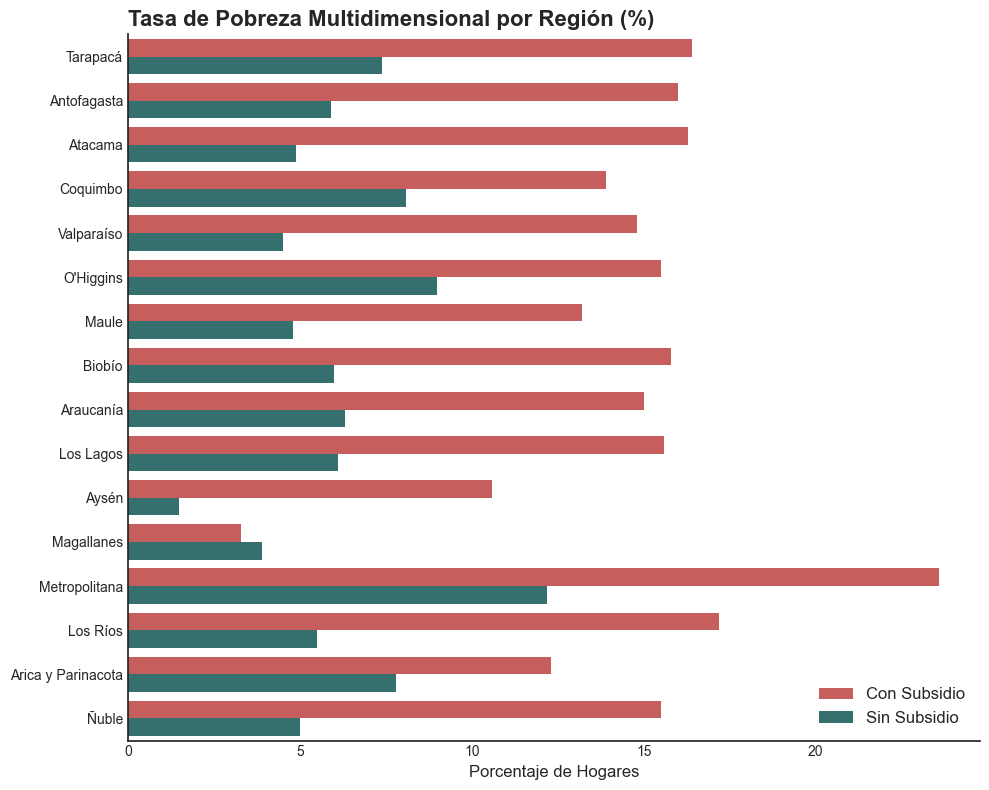

In [4]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
sns.barplot(data=df_grafico_regional, y='Nombre_Region', x='Pobreza_%', hue='Subsidio', palette=[COLOR_SUB, COLOR_NO_SUB], ax=ax)
ax.set_title('Tasa de Pobreza Multidimensional por Región (%)', fontsize=16, fontweight='bold', loc='left')
ax.set_xlabel('Porcentaje de Hogares', fontsize=12)
ax.set_ylabel('')
ax.legend(title='', loc='lower right', frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

### Gráfico B: Seguridad (Balaceras, Tráfico)

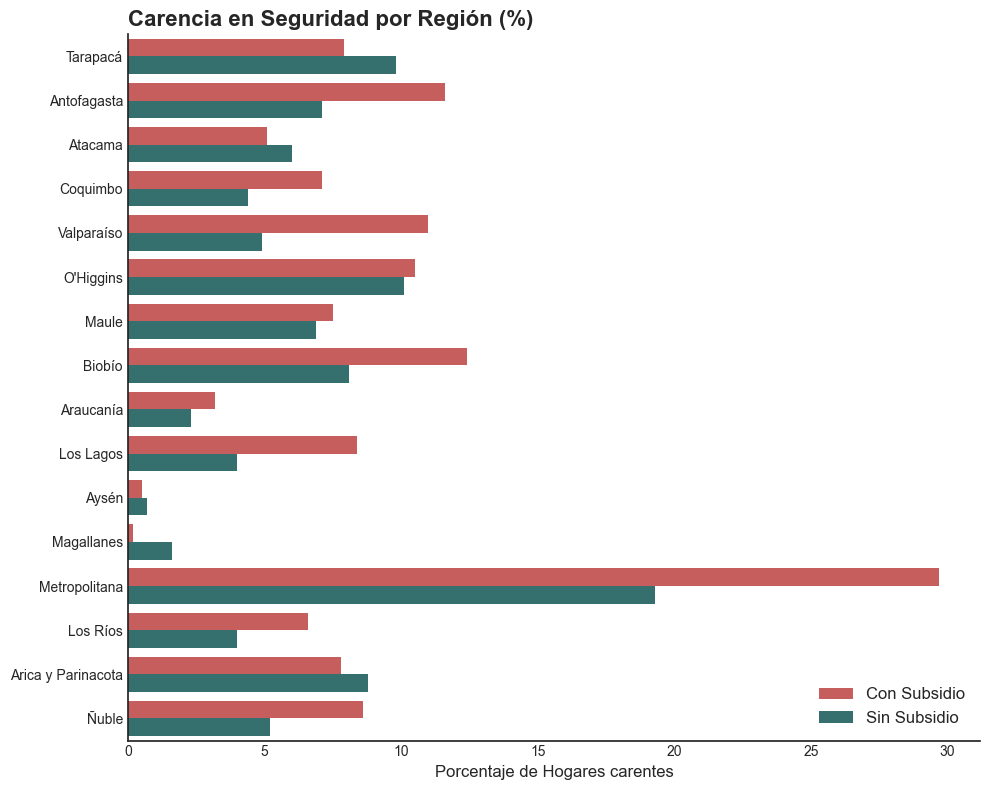

In [5]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
sns.barplot(data=df_grafico_regional, y='Nombre_Region', x='Seguridad_%', hue='Subsidio', palette=[COLOR_SUB, COLOR_NO_SUB], ax=ax)
ax.set_title('Carencia en Seguridad por Región (%)', fontsize=16, fontweight='bold', loc='left')
ax.set_xlabel('Porcentaje de Hogares carentes', fontsize=12)
ax.set_ylabel('')
ax.legend(title='', loc='lower right', frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

### Gráfico C: Entorno Urbano (Calles, Basurales)

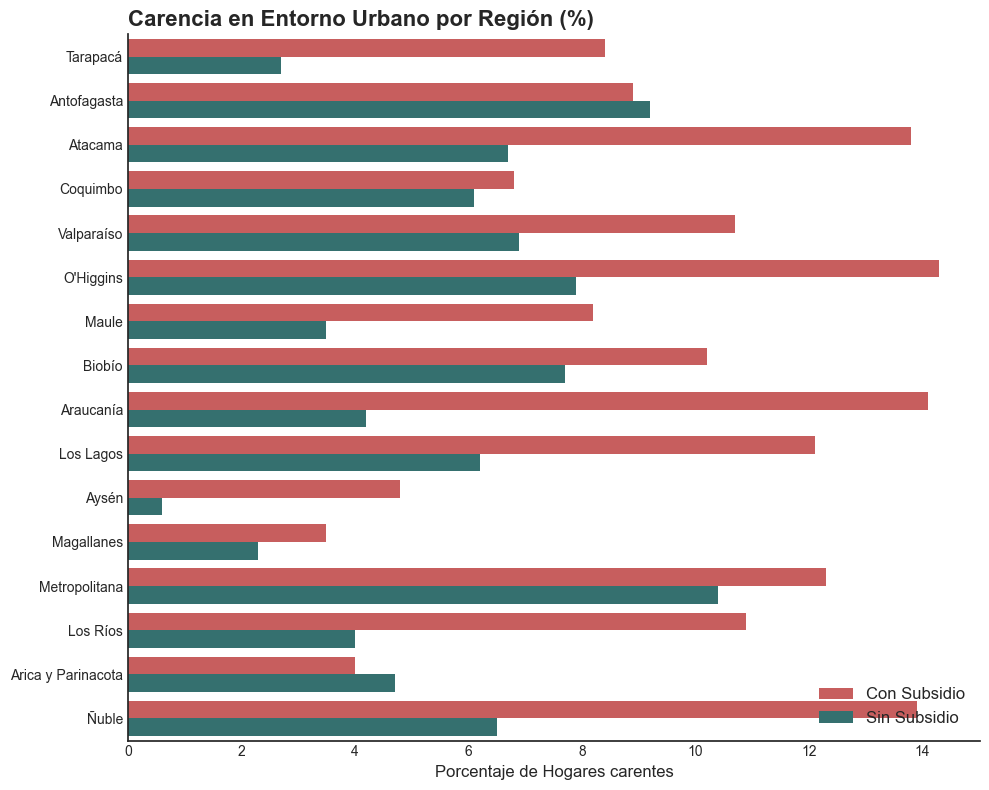

In [6]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
sns.barplot(data=df_grafico_regional, y='Nombre_Region', x='Entorno_%', hue='Subsidio', palette=[COLOR_SUB, COLOR_NO_SUB], ax=ax)
ax.set_title('Carencia en Entorno Urbano por Región (%)', fontsize=16, fontweight='bold', loc='left')
ax.set_xlabel('Porcentaje de Hogares carentes', fontsize=12)
ax.set_ylabel('')
ax.legend(title='', loc='lower right', frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

### Gráfico D: Hacinamiento

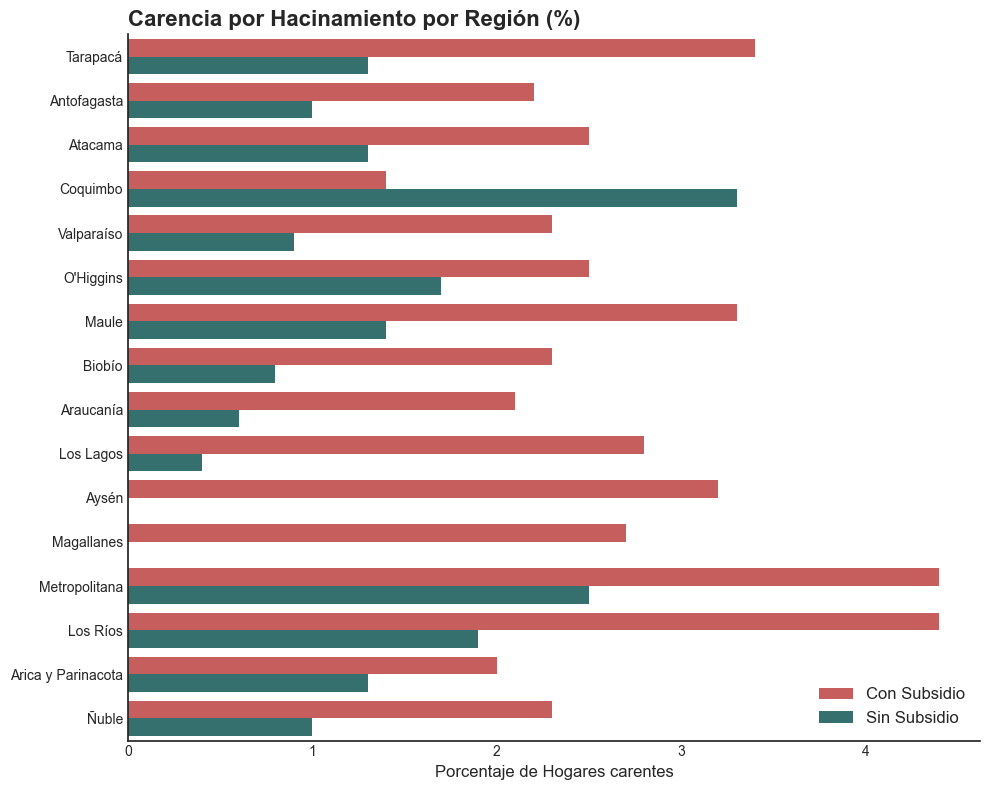

In [7]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
sns.barplot(data=df_grafico_regional, y='Nombre_Region', x='Hacinamiento_%', hue='Subsidio', palette=[COLOR_SUB, COLOR_NO_SUB], ax=ax)
ax.set_title('Carencia por Hacinamiento por Región (%)', fontsize=16, fontweight='bold', loc='left')
ax.set_xlabel('Porcentaje de Hogares carentes', fontsize=12)
ax.set_ylabel('')
ax.legend(title='', loc='lower right', frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

### Gráfico E: Accesibilidad (Lejanía de Servicios)

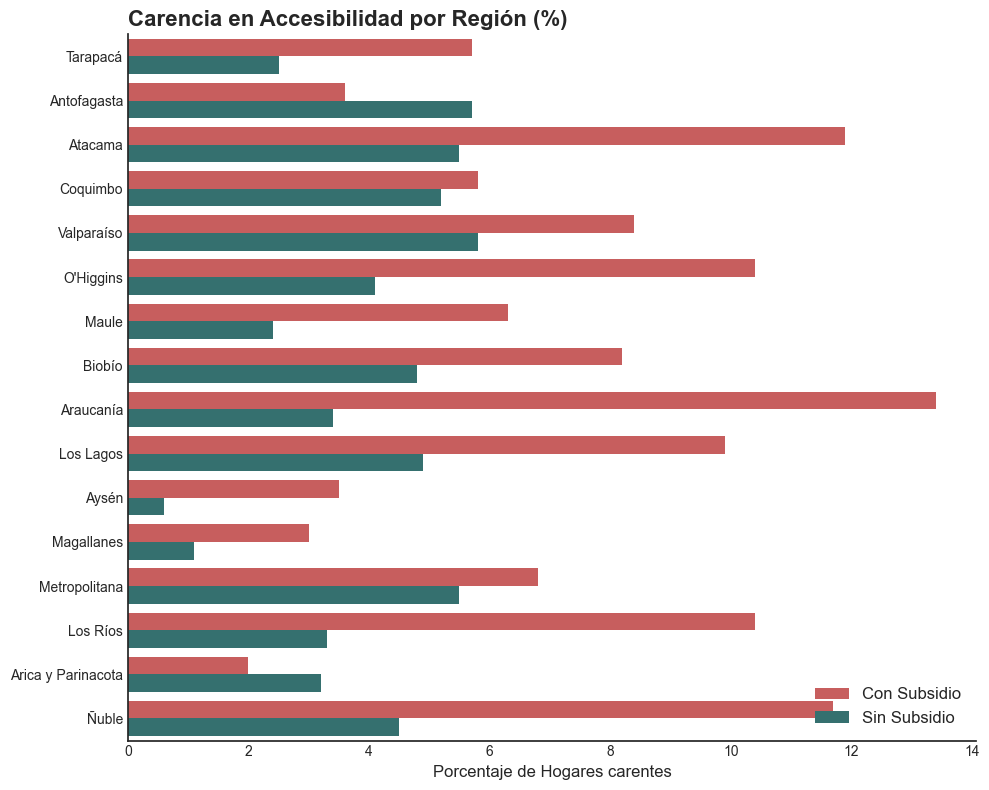

In [8]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
sns.barplot(data=df_grafico_regional, y='Nombre_Region', x='Accesibilidad_%', hue='Subsidio', palette=[COLOR_SUB, COLOR_NO_SUB], ax=ax)
ax.set_title('Carencia en Accesibilidad por Región (%)', fontsize=16, fontweight='bold', loc='left')
ax.set_xlabel('Porcentaje de Hogares carentes', fontsize=12)
ax.set_ylabel('')
ax.legend(title='', loc='lower right', frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

### Gráfico F: Estado de la Vivienda

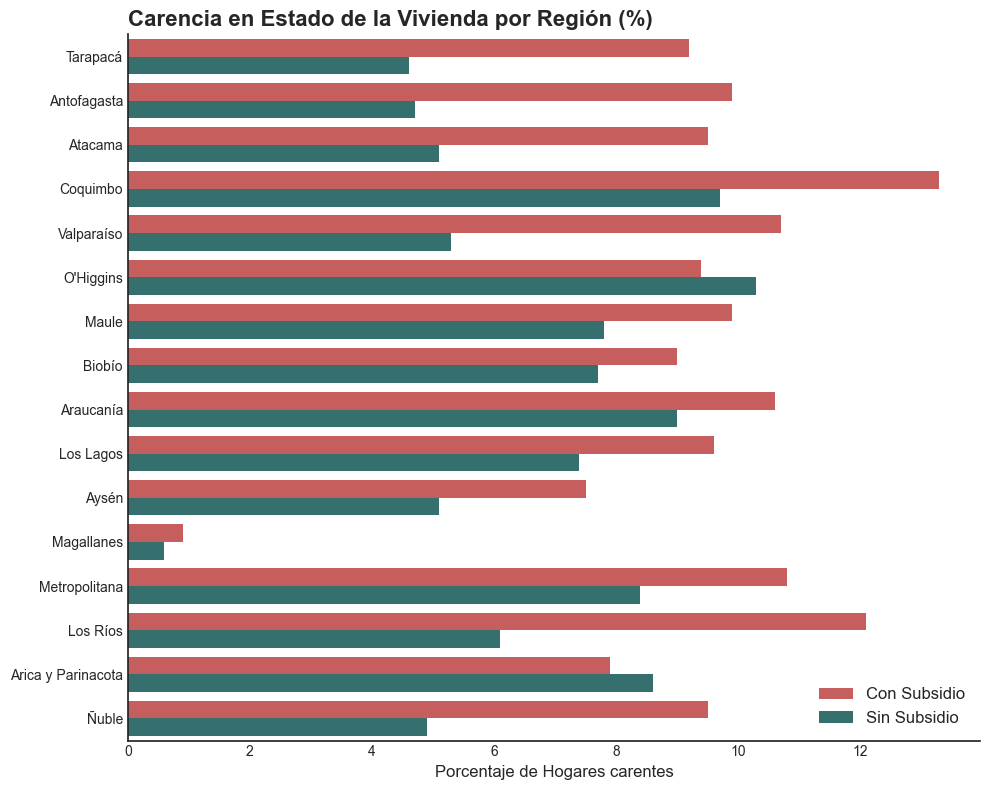

In [9]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
sns.barplot(data=df_grafico_regional, y='Nombre_Region', x='Estado_Vivienda_%', hue='Subsidio', palette=[COLOR_SUB, COLOR_NO_SUB], ax=ax)
ax.set_title('Carencia en Estado de la Vivienda por Región (%)', fontsize=16, fontweight='bold', loc='left')
ax.set_xlabel('Porcentaje de Hogares carentes', fontsize=12)
ax.set_ylabel('')
ax.legend(title='', loc='lower right', frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

### Gráfico G: Ingreso Autónomo

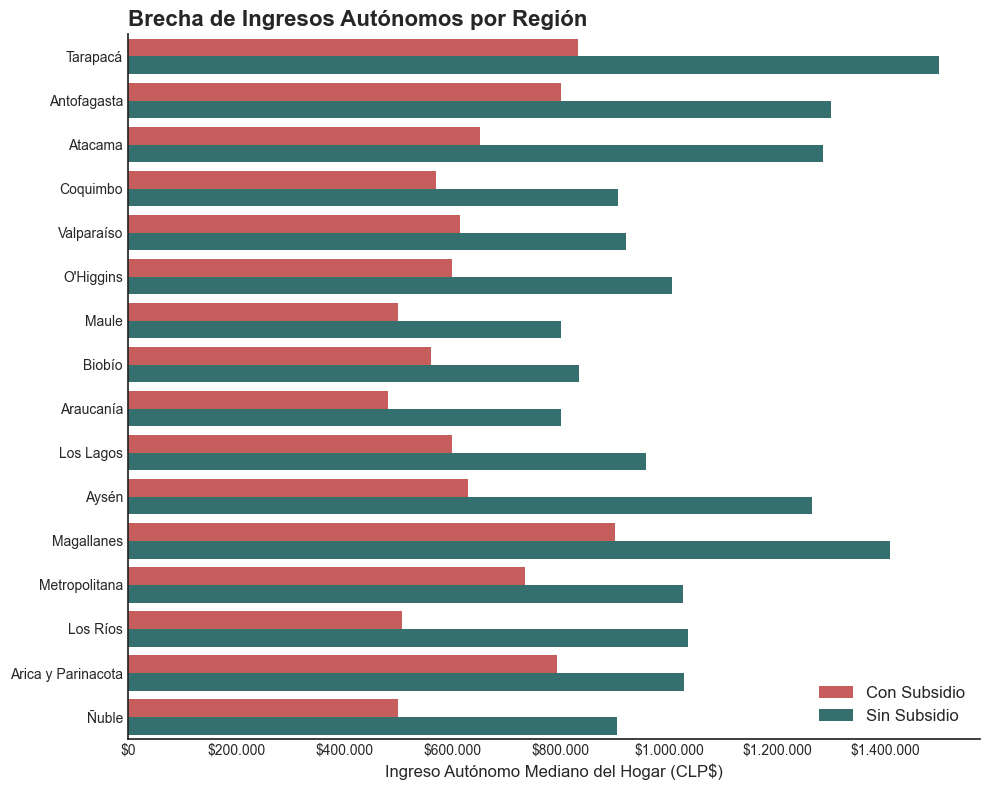

In [10]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
sns.barplot(data=df_grafico_regional, y='Nombre_Region', x='Ingreso_Mediano', hue='Subsidio', palette=[COLOR_SUB, COLOR_NO_SUB], ax=ax)
ax.set_title('Brecha de Ingresos Autónomos por Región', fontsize=16, fontweight='bold', loc='left')
ax.set_xlabel('Ingreso Autónomo Mediano del Hogar (CLP$)', fontsize=12)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}".replace(',', '.')))
ax.legend(title='', loc='lower right', frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. CONCLUSIÓN: RANKING DE FRACTURAS (POR DIMENSIÓN SEPARADA)
Analizamos algorítmicamente las brechas (Diferencia de precariedad entre tener y no tener subsidio). A continuación, **separamos cada dimensión en un gráfico propio** para identificar cuáles son las 3 regiones más castigadas en cada aspecto, sumando el contexto demográfico de por qué ocurren estas desviaciones territoriales.

In [11]:
# --- PREPARACIÓN DE DATOS DE BRECHAS ---
df_pivot = df_grafico_regional.pivot(index='Nombre_Region', columns='Subsidio', 
                                     values=['Pobreza_%', 'Seguridad_%', 'Entorno_%', 
                                             'Hacinamiento_%', 'Estado_Vivienda_%', 'Accesibilidad_%']).reset_index()

df_pivot.columns = ['Nombre_Region'] + [f"{col[0]}_{col[1]}" for col in df_pivot.columns[1:]]

df_pivot['Brecha_Pobreza'] = df_pivot['Pobreza_%_Con Subsidio'] - df_pivot['Pobreza_%_Sin Subsidio']
df_pivot['Brecha_Seguridad'] = df_pivot['Seguridad_%_Con Subsidio'] - df_pivot['Seguridad_%_Sin Subsidio']
df_pivot['Brecha_Entorno'] = df_pivot['Entorno_%_Con Subsidio'] - df_pivot['Entorno_%_Sin Subsidio']
df_pivot['Brecha_Hacinamiento'] = df_pivot['Hacinamiento_%_Con Subsidio'] - df_pivot['Hacinamiento_%_Sin Subsidio']
df_pivot['Brecha_Estado_Vivienda'] = df_pivot['Estado_Vivienda_%_Con Subsidio'] - df_pivot['Estado_Vivienda_%_Sin Subsidio']
df_pivot['Brecha_Accesibilidad'] = df_pivot['Accesibilidad_%_Con Subsidio'] - df_pivot['Accesibilidad_%_Sin Subsidio']

def plot_top_brecha(df, columna, titulo):
    top_3 = df.sort_values(columna, ascending=False).head(3)
    fig, ax = plt.subplots(figsize=(10, 3.5), dpi=100)
    sns.barplot(data=top_3, x=columna, y='Nombre_Region', color='#8b0000', ax=ax)
    
    ax.set_title(titulo, fontsize=14, fontweight='bold', color='#8b0000', loc='left')
    ax.set_xlabel("Castigo del Subsidio (+ Pts. Porcentuales)", fontsize=11)
    ax.set_ylabel("")
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    for p in ax.patches:
        ax.annotate(f"+{p.get_width():.1f} pts", 
                    (p.get_width() - 0.2, p.get_y() + p.get_height() / 2.),
                    ha='right', va='center', fontsize=12, color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("Motor de cálculo de brechas inicializado.")

Motor de cálculo de brechas inicializado.


#### Top Brechas: Pobreza Multidimensional

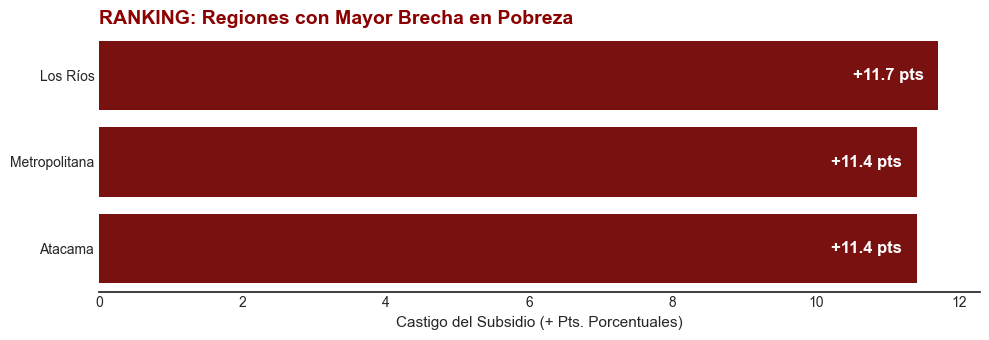

In [12]:
plot_top_brecha(df_pivot, 'Brecha_Pobreza', 'RANKING: Regiones con Mayor Brecha en Pobreza')

**Contexto Territorial:** En el extremo norte (ej. Tarapacá), el alto costo de vida empuja a que las viviendas subsidiadas se construyan en periferias desérticas extremas. Esto desconecta a las familias de las fuentes laborales formales y de los centros económicos, estancándolas en la pobreza a pesar de haber recibido "la casa propia".

#### Top Brechas: Seguridad (Delincuencia)

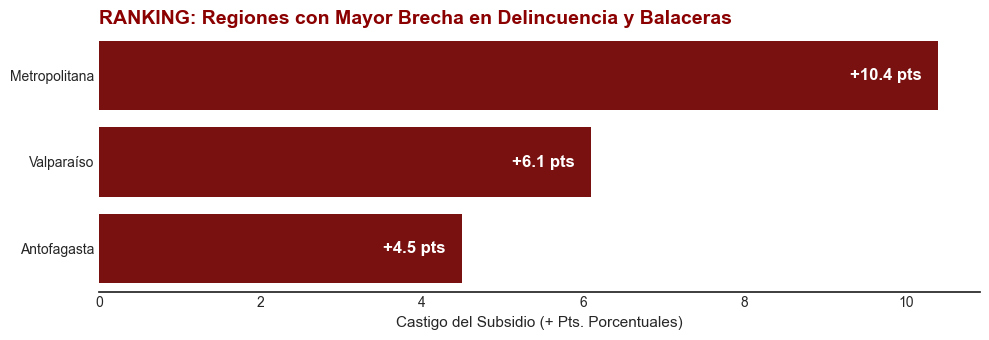

In [13]:
plot_top_brecha(df_pivot, 'Brecha_Seguridad', 'RANKING: Regiones con Mayor Brecha en Delincuencia y Balaceras')

**Contexto Territorial:** Las grandes urbes sufren de alta segregación socioespacial. Los conjuntos habitacionales subsidiados construidos en las últimas décadas fueron emplazados en polígonos con nula presencia estatal y servicios básicos, convirtiéndose en terrenos altamente vulnerables a la captura por bandas de narcotráfico.

#### Top Brechas: Entorno Urbano

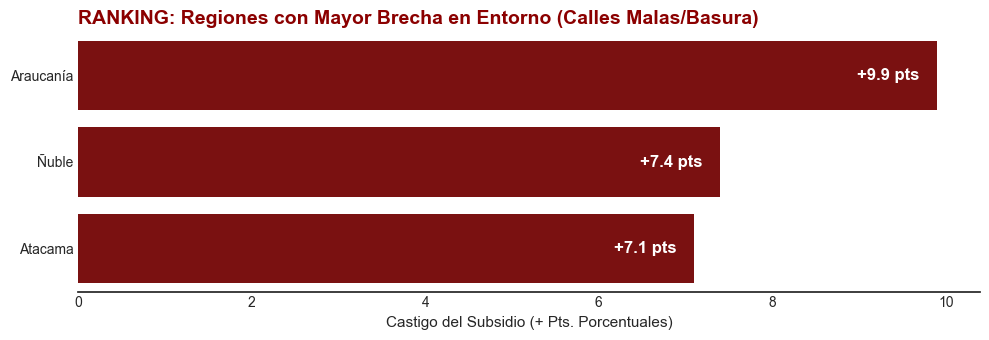

In [14]:
plot_top_brecha(df_pivot, 'Brecha_Entorno', 'RANKING: Regiones con Mayor Brecha en Entorno (Calles Malas/Basura)')

**Contexto Territorial:** El diseño de la política habitacional dependiente del suelo más barato obligó a que históricamente los subsidios masivos se materializaran en bordes industriales, zonas sin pavimentación consolidada o sectores periurbanos, condenando a las familias a convivir con basurales clandestinos y falta de áreas verdes.

#### Top Brechas: Hacinamiento

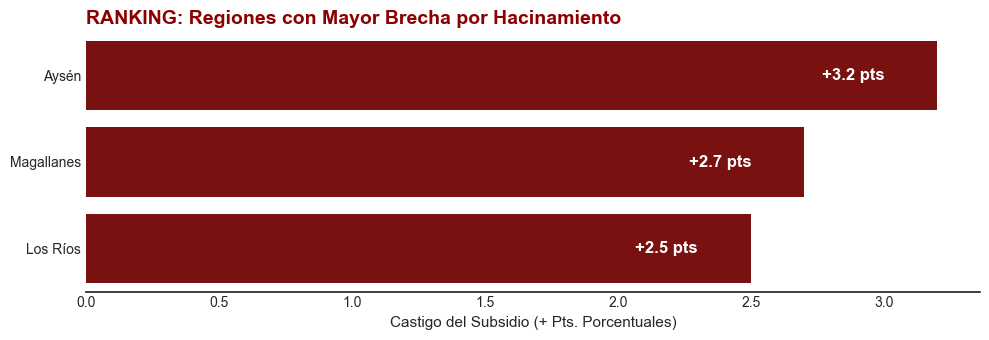

In [15]:
plot_top_brecha(df_pivot, 'Brecha_Hacinamiento', 'RANKING: Regiones con Mayor Brecha por Hacinamiento')

**Contexto Territorial:** El norte chileno concentra el mayor déficit habitacional impulsado por la llegada de migración internacional y migración interregional por la minería. La vivienda subsidiada suele tener un metraje cuadrado sumamente rígido que no se adapta al crecimiento del grupo familiar extendido, generando allegamiento y hacinamiento intradomiciliario agudo.

#### Top Brechas: Accesibilidad a Servicios

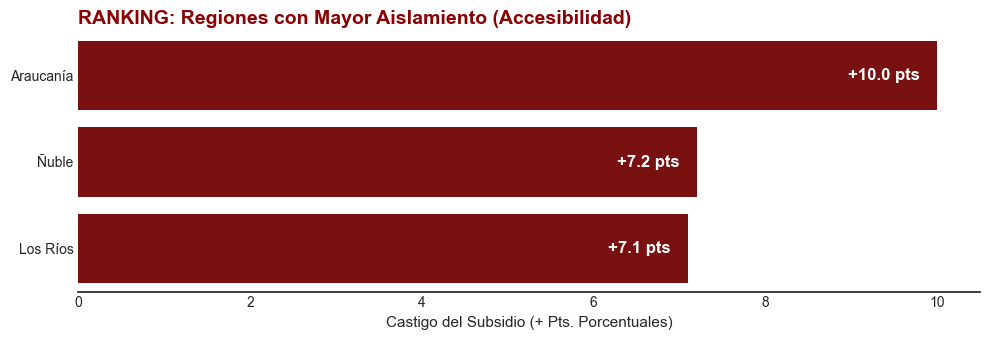

In [16]:
plot_top_brecha(df_pivot, 'Brecha_Accesibilidad', 'RANKING: Regiones con Mayor Aislamiento (Accesibilidad)')

**Contexto Territorial:** En la macrozona sur profunda (Aysén, Los Lagos), la construcción de conjuntos subsidiados sin planificación urbana significa alejar a la familia de colegios, hospitales y farmacias. La geografía agreste o insular multiplica los tiempos de viaje, encareciendo y dificultando brutalmente la vida diaria.

#### Top Brechas: Estado de la Vivienda

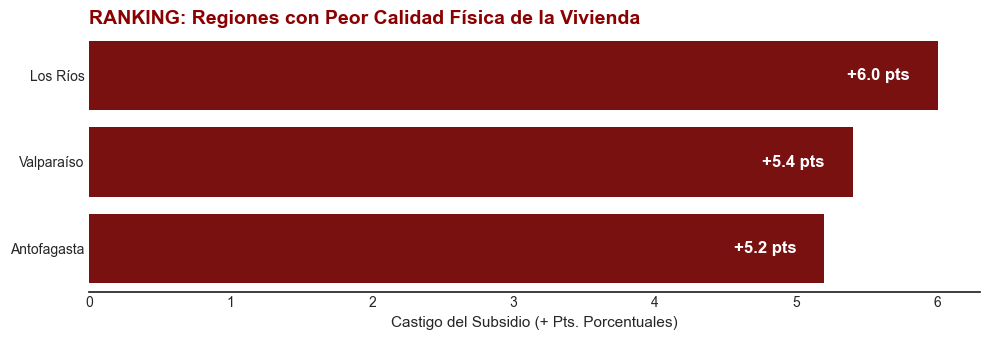

In [17]:
plot_top_brecha(df_pivot, 'Brecha_Estado_Vivienda', 'RANKING: Regiones con Peor Calidad Física de la Vivienda')

**Contexto Territorial:** Ciertas regiones sufren las secuelas de la política masiva de construcción de vivienda social de los años 90. Estas viviendas (los conocidos "bloques") evidencian hoy un deterioro estructural severo por el uso inicial de materiales económicos y la incapacidad espacial de realizar mantenciones o ampliaciones seguras.